In [1]:
#   NumPy: 수치 계산(행렬 연산, sigmoid, gradient 계산 등)에 사용합니다.
import numpy as np

#   pandas: 예측 결과를 표(DataFrame) 형태로 보기 좋게 정리한느 데 사용합니다.
import pandas as pd

from math import e
#   matplotlib: 산점도 결정 경계 그래프를 그리는 데 사용합니다.
import matplotlib.pyplot as plt

#   이번 노트북은 딥러닝 프레임워크(TensorFlow, PyTorch) 없이
#   단일 퍼셉트론의 원리 NumPy로 직접 구현하여 확인합니다.
#   seaborn 도 사용하지 않습니다.(matplotlib 만 사용)

#   random seed 를 고정합니다.
#   seef 를 고정하면 이 노트북을 다시 실행해도 항상 같은 결과가 나옵니다.
np.random.seed(42)

print('라이브러리 import 완료')

라이브러리 import 완료


In [2]:
#   온도(temperature), 습도(humidity), 정답(y) 데이터를 직접 만듭니다.
#   외부 파일을 읽지 않고, 코드 안에서 값을 그대로 정의합니다.
#
#   구조를 다시 확인합니다.
#       낮은 구간(온도 10 ~ 15) → y = 0
#       중간 구간(온도 22 ~ 28) → y = 1
#       높은 구간(온도 35 ~ 38) → y = 0
data = {
    'temperature': [10, 15, 20, 25, 30, 35],
    'humidity':    [30, 40, 50, 60, 70, 80],
    'y':           [ 0,  0,  1,  1,  1,  0]
}

#   pandas DataFrame 으로 만들어 표 형태로 다룹니다.
df = pd.DataFrame(data)

#   데이터 전체를 출력하여 확인합니다.
df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,20,50,1
3,25,60,1
4,30,70,1
5,35,80,0


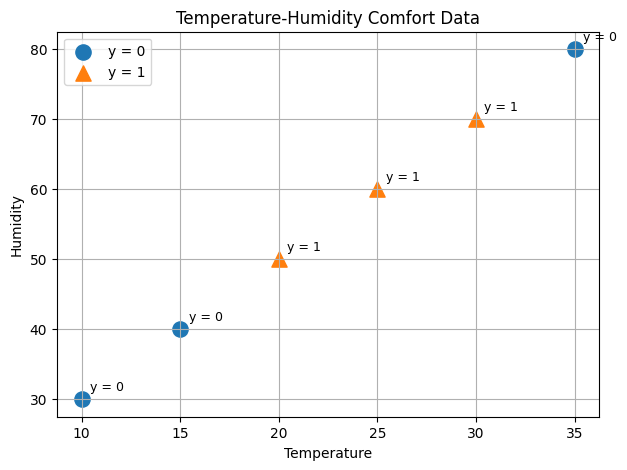

In [4]:
#   그림(figure) 하나들 만듭니다.
plt.figure(figsize = (7, 5))

#   y = 0인 점과 y = 1 인 점을 나누어 서로 다른 marker 로 그립니다.
#   boolean indexing: df['y'] == 0 인 행말 골라냅니다.
mask0 = df['y'] == 0    #   y가 0인 행(쾌적하지 않음)
mask1 = df['y'] == 1    #   y가 1인 행(쾌적함)

#   y=0 그룹: marker = 'O'  (동그라미)
plt.scatter(df.loc[mask0, 'temperature'], df.loc[mask0 ,'humidity'],
            marker = 'o', s=120, label = 'y = 0')

#   y=1 그룹: marker = '^'  (삼각형)
plt.scatter(df.loc[mask1, 'temperature'], df.loc[mask1, 'humidity'],
            marker = '^', s = 120, label = 'y = 1')

#   각 점 옆에 y 값을 작게 표시합니다.
#   zip으로 (온도, 습도, y) 를 한 줄씩 꺼내면서 텍스트를 붙입니다.
for temp, hum, yv in zip(df['temperature'], df['humidity'], df['y']):
    plt.annotate(f'y = {yv}', (temp, hum),
                 textcoords = 'offset points', xytext = (6, 6), fontsize = 9)
    
#   축 라벨, 제목, 범례, 격자 설정
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.title('Temperature-Humidity Comfort Data')
plt.legend()
plt.grid(True)

plt.show()

In [5]:
#   X_raw: 원본 입력값. 온도와 습도를 나란히 붙여 (행의 수, 2) 모양으로 만듭니다.
#           shape = (n, 2)  →   열 0 = 온도, 열 1 = 습도
X_raw = df[['temperature', 'humidity']].to_numpy(dtype = float)

#   y: 실제 정답. (n, 1) 모양의 세로 벡터로 만듭니다.

#   reshape(-1, 1) 의 의미를 자세히 봅니다.
#       - 첫 번째 값 -1 : '행 개수는 자동으로 맞춰라' 라는 뜻입니다.
#                        (전체 개수를 보고 NumPy 가 알아서 행 수를 계산합니다.)
#       - 두 번째 값  1 : '열은 1개로 만들어라' 라는 뜻입니다.
#   즉 reshape(-1, 1) 은 값들을 (n, 1) 모양의 '세로 벡터' 로 세운라는 뜻입니다.
#   이렇게 y, z, H 를 모두 (n, 1) 모양으로 맞추면, 곱셈/뺄셈 계산이 어긋나지 않고 안전합니다.
y = df['y'].to_numpy(dtype = float).reshape(-1, 1)

In [6]:
#   X_mean: 각 입력 컬럼(온도, 습도)의 평균.
#           axis = 0은 '열 방향으로 계산' = 컬럼별 평균 이라는 뜻입니다.
X_mean = X_raw.mean(axis = 0, keepdims = True)  #   shape = (1, 2)

#   X_std: 각 입력 컬럼의 표준편차.
X_std = X_raw.std(axis = 0, keepdims = True)    #   shape = (1, 2)

#   X_norm: 정규화된 입력값. (원본 - 평균) / 표준편차
#           X_raw는 (n, 2), X_mean/X_std 는 (1, 2)이지만
#           NumPy 브로드캐스팅 덕분에 컬럼별로 자동 계산됩니다.

#   [정규화를 왜, 어디에 쓰는지 정리]
#       - 학습(Gradient Descent)에는 정규화된 값 X_norm을 사용합니다.
#         → 온도(10~38)와 습도(30~80)처럼 범위가 다른 값을 그대로 넣으면 학습이 불안정하기 때문입니다.
#       - 반대로 그래프와 결과 해석에는 원래 온도·습도 단위(X_raw)를 사용합니다.
#         → 사람은 '온도 25도, 습도 55%' 처럼 원래 단위가 훨씬 이애하기 쉽기 때문입니다.
#   즉, 컴퓨터 학습에는 정규화된 값이 안정적이고,
#       사람 해석에는 원래 단위가 편하므로, 둘을 목적에 맞게 나누어 씁니다.
X_norm = (X_raw - X_mean) / X_std               # shape = (n, 2)

In [7]:
#   확인용으로 평균과 표준편차를 출력합니다.
print('X_mean   (온도평균, 습도평균): ', X_mean)
print('X_std    (온도표준편차, 습도표준편차): ', X_std)
print('X_norm shape: ', X_norm.shape)
print('y shape: ', y.shape)

X_mean   (온도평균, 습도평균):  [[22.5 55. ]]
X_std    (온도표준편차, 습도표준편차):  [[ 8.53912564 17.07825128]]
X_norm shape:  (6, 2)
y shape:  (6, 1)


In [10]:
#   정규화된 값을 DataFrame 에  새 컬럼으로 추가해 원본과 함께 봅니다.
#   여기서는 표에 보기 좋게 넣기만 할 것이므로 (n,) 1ㅏ추언 형태인 X_norm[:, 0] 을 사용합니다.
#   (학습 코드에서는 y 와 모양을 맞추려고 (n, 1) 형태인 X_norm[:, [0]] 를 사용합니다. 뒤에서 다시 설명합니다.)
#   참고: (n,) 와 (n, 1) 은 모양이 다르며, 브로드캐스팅 방식이 달라져 계산 결과가 달라질 수 있으므로 목적에 맞게 구분해서 씁니다.
df['temperature_norm'] = X_norm[:, 0]   # 정규화된 온도
df['humidity_norm'] = X_norm[:, 1]      # 정규화된 습도

df

,temperature,humidity,y,temperature_norm,humidity_norm
0,10,30,0,-1.46385,-1.46385
1,15,40,0,-0.87831,-0.87831
2,20,50,1,-0.29277,-0.29277
3,25,60,1,0.29277,0.29277
4,30,70,1,0.87831,0.87831
5,35,80,0,1.46385,1.46385


In [11]:
def sigmoid(H):
    #   H 는 sigmoid 이전의 선형 출력값입니다.   (확률이 아님)
    #   H 가 아주 크거나 아주 작으면 exp 계산에서 overflow(값이 너무 커짐)가 날 수 있습니다.
    #   그래서 H를 -500 ~ 500 사이로 잘라(clip) 계산을 안정적으로 만듭니다.
    H_clip = np.clip(H, -500, 500)
    
    #   sigmoid 공식: 1 / (1 + e^(-H))
    #   반환값 z 는 항상 0과 1 사이의 예측확률입니다.
    z = 1.0 / (1.0 + e ** (-H_clip))
    return z

#   동작을 확인합니다.
#   H = 0이면, z = 0.5, H가 크면 z는 1에 가까워지고, H가 작으면 z는 0에 가까워집니다.
print('sigmoid(0)   =', sigmoid(np.array(0.0)))
print('sigmoid(10)  =', sigmoid(np.array(10.0)))
print('sigmoid(-10) =', sigmoid(np.array(-10.0)))

sigmoid(0)   = 0.5
sigmoid(10)  = 0.9999546021312976
sigmoid(-10) = 4.539786870243442e-05
